In [1]:
import numpy as np
import time

# Gerade und ungerade teile der Simpson Regel trennen
SPLIT = False

$ y(t) = 5 - 1.3 \cdot t + t^2 -0.05 \cdot t^3 $

Stammfunktion $ Y(t) = 5 \cdot t - 0.65 \cdot t^2 + 1/3 \cdot t^3 - 0.0125 \cdot t^4 $

In [2]:
def y_func(x):
    return 5 - 1.3 * x + x**2 - 0.05 * x**3

def y_int(x):
    return 5 * x - 1.3 * 1/2 * x**2 + 1/3 * x**3 - 0.05 * 1/4 * x**4

## a) Analytische Lösung

In [3]:
# Integralgrenzen beachten, gefordertes Intervall [-5 20]

t_bounds = np.array([-5, 20])

# Berechnung der Stammfunktion an den Grenzen
# Hinweis: In Python ** für Potenz verwenden, nicht ^
int_vals = y_int(t_bounds)

# Hauptsatz der Integralrechnung: F(b) - F(a)
# int_vals[1] ist Obergrenze, int_vals[0] ist Untergrenze
int_analytic = int_vals[1] - int_vals[0]

print(f"Analytisches Ergebnis: {int_analytic}")

Analytisches Ergebnis: 597.3958333333331


## b) Numerische Lösung

In [4]:
# Schrittweite
T = 2

# Diskreter Zeitvektor
# np.arange schließt den Endwert aus, daher +T/100 als kleiner Puffer
t = np.arange(t_bounds[0], t_bounds[1] + T/2, T)

# Diskrete Folge
x = y_func(t)

print(f"Anzahl der Punkte: {t.shape=} {x.shape=}")

Anzahl der Punkte: t.shape=(13,) x.shape=(13,)


### Trapezregel
$$ y_n = y_{n-1} + T \cdot \frac{x_n + x_{n-1}}{2}, \quad y_0 = 0 $$

In [5]:
print("Starte Trapez...")
start_time = time.time()

# Langsam!
# int_trapez = np.zeros(x.size)
# for k in range(1, x.size):
#     int_trapez[k] = int_trapez[k-1] + (T/2) * (x[k] + x[k-1])

# Wir berechnen die Summe direkt ohne Schleife
int_trapez = T/2 * np.cumsum(x[1:] + x[:-1])
int_trapez = np.insert(int_trapez, 0, 0.0, axis=0)

end_time = time.time()
print(f"Trapez Zeit: {end_time - start_time:.4e} sek")
print(f"Anzahl der Punkte: {int_trapez.shape=}")

Starte Trapez...
Trapez Zeit: 1.8024e-04 sek
Anzahl der Punkte: int_trapez.shape=(13,)


### Simpsonsregel
$$ y_{n+1} = y_{n-1} + T \cdot \frac{x_{n-1} + 4 \cdot x_n + x_{n+1}}{3}, \quad y_0 = 0 $$

In [10]:
print("Starte Simpson-Schleife...")
start_time = time.time()

int_simpson = np.zeros(x.size)
int_simpson[1] = T * (x[0] + x[1]) / 2
for k in range(2, x.size):
    int_simpson[k] = int_simpson[k-2] + (T/3) * (x[k-2] + 4*x[k-1] + x[k])

# local_areas = (T/3) * (x[:-2] + 4*x[1:-1] + x[2:])

# int_even = np.cumsum(local_areas[::2])
# int_odd  = np.cumsum(local_areas[1::2])

# int_simpson = np.zeros(len(x))
# int_simpson[2::2] = int_even
# int_simpson[3::2] = int_odd[:len(int_simpson[3::2])]

end_time = time.time()
print(f"Simpson Loop Zeit: {end_time - start_time:.4e} sek")
print(f"Anzahl der Punkte: {int_simpson.shape=}")

Starte Simpson-Schleife...
Simpson Loop Zeit: 1.6284e-04 sek
Anzahl der Punkte: int_simpson.shape=(13,)


### Auswertung

In [7]:
import pandas as pd

err_trapez  = (int_trapez[-1]  - int_analytic) / int_analytic * 100
err_simpson = (int_simpson[-1] - int_analytic) / int_analytic * 100

data = {
    'Analytic':        [int_analytic, 0.0],
    'Trapez':          [int_trapez[-1], err_trapez],
    'Simpson Gerade':  [int_simpson[-1], err_simpson]
}

df = pd.DataFrame(data, index=['Result', 'Rel. Err. [%]'])

df.style.format("{:.5e}")

,Analytic,Trapez,Simpson Gerade
Result,5.97396e+02,6.07600e+02,6.08400e+02
Rel. Err. [%],0.00000e+00,1.70811e+00,1.84202e+00


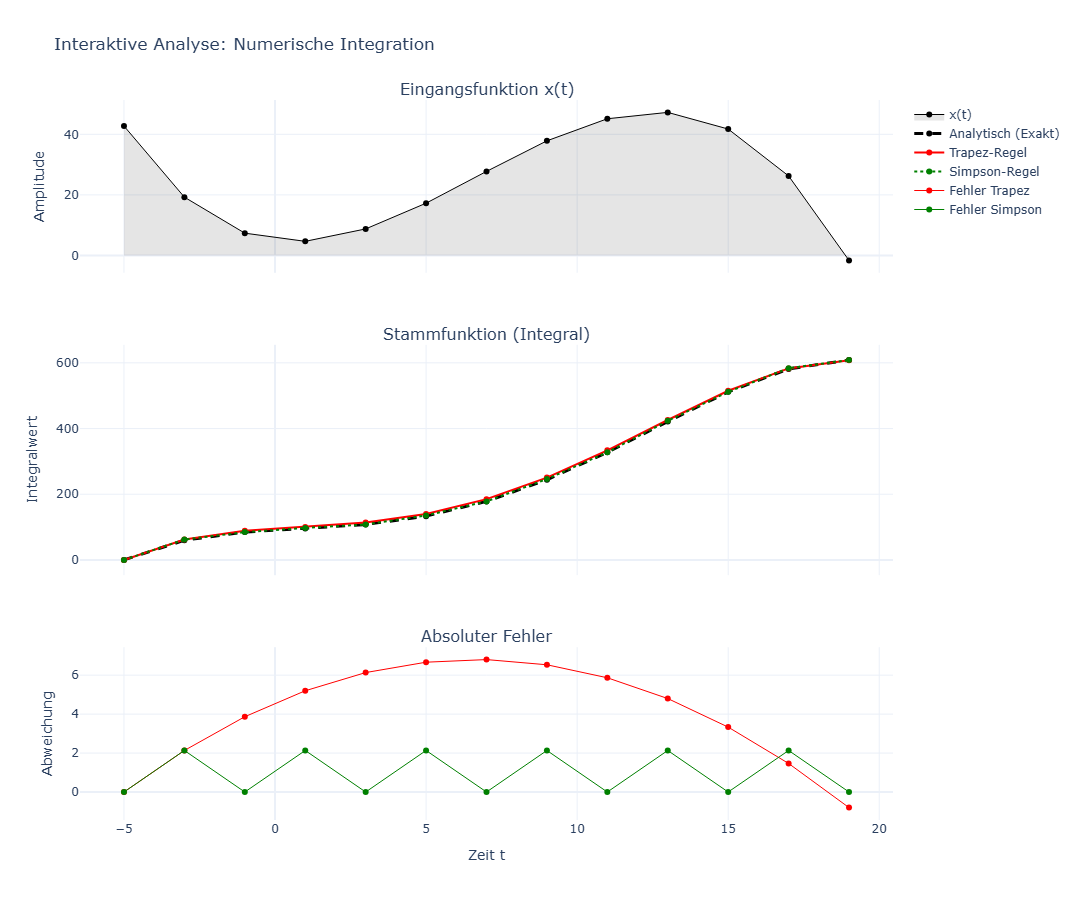

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. Vorbereitung der analytischen Kurve über die Zeit ---
# Wir brauchen die analytische Lösung für JEDEN Zeitschritt t, 
# nicht nur für die Grenzen, um den Fehler zu plotten.
F_t = 5*t - 0.65*t**2 + (1/3)*t**3 - 0.0125*t**4

# Wichtig: Die numerische Integration startet bei 0.
# Die analytische Stammfunktion hat bei t=-5 einen Wert. 
# Wir müssen diesen Startwert abziehen, damit beide bei 0 starten.
F_t_normalized = F_t - F_t[0]

# --- 2. Berechnung des Fehlers über die Zeit ---
error_trapez_curve = (int_trapez - F_t_normalized)
error_simpson_curve = (int_simpson - F_t_normalized)

# Daten-Sampling (damit der Browser nicht abstürzt bei Millionen Punkten)
# Wir nehmen z.B. nur jeden 100. Punkt für die Grafik. 
# Das reicht für das Auge völlig aus, erhält aber die Form.
step = 100 if len(t) > 10000 else 1 

t_plot = t[::step]

# Subplots erstellen (3 Zeilen, geteilte X-Achse)
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Eingangsfunktion x(t)", "Stammfunktion (Integral)", "Absoluter Fehler"),
    row_heights=[0.3, 0.4, 0.3]
)

# --- 1. Eingangsfunktion ---
fig.add_trace(
    go.Scatter(
        x=t_plot,
        y=x[::step],
        name="x(t)", 
        line=dict(color='black', width=1),
        fill='tozeroy',
        fillcolor='rgba(0,0,0,0.1)'
    ), row=1, col=1
)

# --- 2. Integral-Vergleich ---
fig.add_trace(
    go.Scatter(
        x=t_plot,
        y=F_t_normalized[::step],
        name="Analytisch (Exakt)",
        line=dict(color='black', width=3, dash='dash')
    ), row=2, col=1
)
fig.add_trace(
    go.Scatter(
        x=t_plot,
        y=int_trapez[::step],
        name="Trapez-Regel",
        line=dict(color='red', width=2)
    ), row=2, col=1
)
if SPLIT:
    fig.add_trace(
        go.Scatter(
            x=t_plot[::2],
            y=(int_simpson[::step])[::2],
            name="Simpson-Regel Gerade",
            line=dict(color='green', width=2, dash='dot')
        ), row=2, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=t_plot[1::2],
            y=(int_simpson[::step])[1::2],
            name="Simpson-Regel Ungerade",
            line=dict(color='blue', width=2, dash='dot')
        ), row=2, col=1
    )
else:
    fig.add_trace(
        go.Scatter(
            x=t_plot,
            y=int_simpson[::step],
            name="Simpson-Regel",
            line=dict(color='green', width=2, dash='dot')
        ), row=2, col=1
    )

# --- 3. Fehler-Verlauf ---
fig.add_trace(
    go.Scatter(
        x=t_plot,
        y=error_trapez_curve[::step],
        name="Fehler Trapez",
        line=dict(color='red', width=1)
    ), row=3, col=1
)
if SPLIT:
    fig.add_trace(
        go.Scatter(
            x=t_plot[::2],
            y=(error_simpson_curve[::step])[::2],
            name="Fehler Simpson Gerade",
            line=dict(color='green', width=1)
        ), row=3, col=1
    )
    fig.add_trace(
        go.Scatter(
            x=t_plot[1::2],
            y=(error_simpson_curve[::step])[1::2],
            name="Fehler Simpson Ungerade",
            line=dict(color='blue', width=1)
        ), row=3, col=1
    )
else:
    fig.add_trace(
        go.Scatter(
            x=t_plot,
            y=error_simpson_curve[::step],
            name="Fehler Simpson",
            line=dict(color='green', width=1)
        ), row=3, col=1
    )

# Layout aufhübschen
fig.update_layout(
    title_text="Interaktive Analyse: Numerische Integration",
    height=900,
    hovermode="x unified",
    template="plotly_white"
)

# Achsenbeschriftungen
fig.update_yaxes(title_text="Amplitude", row=1, col=1)
fig.update_yaxes(title_text="Integralwert", row=2, col=1)
fig.update_yaxes(title_text="Abweichung", row=3, col=1)
fig.update_xaxes(title_text="Zeit t", row=3, col=1)

fig.show()